<div style="background-color:#d4edda; color:#155724; padding:10px; border-radius:8px;">
    
# Analyzing a real world data-set with SQL and Python

## Objectives

*   Understand a dataset of selected socioeconomic indicators in Chicago
*   Learn how to store data in an SQLite database.

## Selected Socioeconomic Indicators in Chicago

The city of Chicago released a dataset of socioeconomic data to the Chicago City Portal.
This dataset contains a selection of six socioeconomic indicators of public health significance and a “hardship index,” for each Chicago community area, for the years 2008 – 2012.

Scores on the hardship index can range from 1 to 100, with a higher index number representing a greater level of hardship.

A detailed description of the dataset can be found on [the city of Chicago's website](https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01), but to summarize, the dataset has the following variables:

*   **Community Area Number** (`ca`): Used to uniquely identify each row of the dataset

*   **Community Area Name** (`community_area_name`): The name of the region in the city of Chicago

*   **Percent of Housing Crowded** (`percent_of_housing_crowded`): Percent of occupied housing units with more than one person per room

*   **Percent Households Below Poverty** (`percent_households_below_poverty`): Percent of households living below the federal poverty line

*   **Percent Aged 16+ Unemployed** (`percent_aged_16_unemployed`): Percent of persons over the age of 16 years that are unemployed

*   **Percent Aged 25+ without High School Diploma** (`percent_aged_25_without_high_school_diploma`): Percent of persons over the age of 25 years without a high school education

*   **Percent Aged Under** 18 or Over 64:Percent of population under 18 or over 64 years of age (`percent_aged_under_18_or_over_64`): (ie. dependents)

*   **Per Capita Income** (`per_capita_income_`): Community Area per capita income is estimated as the sum of tract-level aggragate incomes divided by the total population

*   **Hardship Index** (`hardship_index`): Score that incorporates each of the six selected socioeconomic indicators


<div style="background-color:#d4edda; color:#155724; padding:10px; border-radius:8px;">
    
### Connect to the database

Let us first load the SQL extension and establish a connection with the database

##### The syntax for connecting to magic sql using sqllite is

  **%sql sqlite://DatabaseName**   
  
where DatabaseName will be **socioeconomic.db** file 


In [1]:
!pip install ipython-sql
!pip install seaborn

import seaborn as sns
%load_ext sql

In [2]:
import csv, sqlite3

con = sqlite3.connect('socioeconomic.db')
cur = con.cursor()

In [11]:
%sql sqlite:///socioeconomic.db

In [12]:
!pip install pandas

<div style="background-color:#d4edda; color:#155724; padding:10px; border-radius:8px;">

### Store the dataset in a Table

##### In many cases the dataset to be analyzed is available as a .CSV (comma separated values) file, perhaps on the internet. To analyze the data using SQL, it first needs to be stored in the database.

##### We will first read the csv files  from the given url  into pandas dataframes

##### Next we will be using the  df.to_sql() function to convert each csv file  to a table in sqlite  with the csv data loaded in it.

In [13]:
import pandas
df = pandas.read_csv('https://data.cityofchicago.org/resource/jcxq-k9xf.csv')
df.to_sql("chicago_socioeconomic_data", con, if_exists='replace', index=False,method="multi")

78

In [14]:
# Install the 'ipython-sql' and 'prettytable' libraries using pip
!pip install ipython-sql prettytable

# Import the 'prettytable' library, which is used to display data in a formatted table
import prettytable

# Set the default display format for prettytable to 'DEFAULT' (i.e., a simple table format)
prettytable.DEFAULT = 'DEFAULT'

In [17]:
%sql SELECT * FROM chicago_socioeconomic_data;

 * sqlite:///socioeconomic.db
Done.


ca,community_area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0
2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0
3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0
4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0
5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0
6.0,Lake View,1.1,11.4,4.7,2.6,17.0,60058,5.0
7.0,Lincoln Park,0.8,12.3,5.1,3.6,21.5,71551,2.0
8.0,Near North Side,1.9,12.9,7.0,2.5,22.6,88669,1.0
9.0,Edison Park,1.1,3.3,6.5,7.4,35.3,40959,8.0
10.0,Norwood Park,2.0,5.4,9.0,11.5,39.5,32875,21.0


<div class="alert alert-block alert-info"> Number of rows in the dataset

In [19]:
%%sql 
Select count(*) from chicago_socioeconomic_data;

 * sqlite:///socioeconomic.db
Done.


count(*)
78


<div class="alert alert-block alert-info"> Number of community areas in Chicago have a hardship index greater than 50.0

In [20]:
%%sql
select count(*) from chicago_socioeconomic_data where hardship_index > 50;

 * sqlite:///socioeconomic.db
Done.


count(*)
38


<div class="alert alert-block alert-info"> Maximum value of hardship index in this dataset

In [21]:
%%sql
select max(hardship_index) from chicago_socioeconomic_data;

 * sqlite:///socioeconomic.db
Done.


max(hardship_index)
98.0


<div class="alert alert-block alert-info"> Community area having the highest hardship index

In [23]:
%sql select community_area_name from chicago_socioeconomic_data order by hardship_index desc limit 1;
# %sql select community_area_name from chicago_socioeconomic_data where hardship_index = ( select max(hardship_index) from chicago_socioeconomic_data );

 * sqlite:///socioeconomic.db
Done.


community_area_name
Riverdale


<div class="alert alert-block alert-info"> The Chicago community area having per-capita incomes greater than $60,000

In [24]:
%%sql
select community_area_name from chicago_socioeconomic_data where per_capita_income_ > 60000

 * sqlite:///socioeconomic.db
Done.


community_area_name
Lake View
Lincoln Park
Near North Side
Loop


<div class="alert alert-block alert-info"> A scatter plot using the variables per_capita_income_ and hardship_index. Explaining the correlation between the two variables.

 * sqlite:///socioeconomic.db
Done.


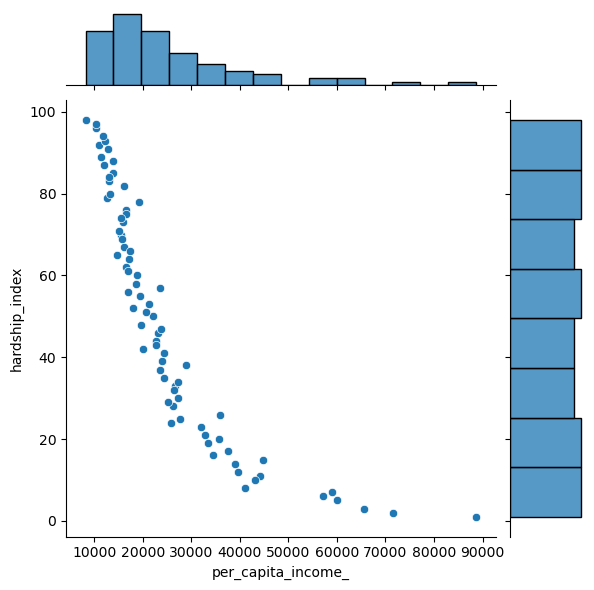

In [25]:
!pip install matplotlib seaborn
income_vs_hardship = %sql SELECT per_capita_income_, hardship_index FROM chicago_socioeconomic_data;
plot = sns.jointplot(x='per_capita_income_',y='hardship_index', data=income_vs_hardship.DataFrame())

<div class="alert alert-block alert-info"> The average per capita income for community areas with a high unemployment rate

In [26]:
%%sql
SELECT AVG(per_capita_income_) AS average_income
FROM chicago_socioeconomic_data
WHERE percent_aged_16_unemployed > 15.0;


 * sqlite:///socioeconomic.db
Done.


average_income
16623.944444444445


<div class="alert alert-block alert-info"> The top 5 community areas with the highest percentage of households below the poverty line, and list their hardship index.

In [27]:
%%sql
SELECT community_area_name, percent_households_below_poverty, hardship_index
FROM chicago_socioeconomic_data
ORDER BY percent_households_below_poverty DESC
LIMIT 5;

 * sqlite:///socioeconomic.db
Done.


community_area_name,percent_households_below_poverty,hardship_index
Riverdale,56.5,98.0
Fuller Park,51.2,97.0
Englewood,46.6,94.0
North Lawndale,43.1,87.0
East Garfield Park,42.4,83.0


 <div class="alert alert-block alert-info"> A scatter plot using the variables Housing Crowded Vs Hardship Index for the percentage of crowded housing units and the hardship index.

 * sqlite:///socioeconomic.db
Done.


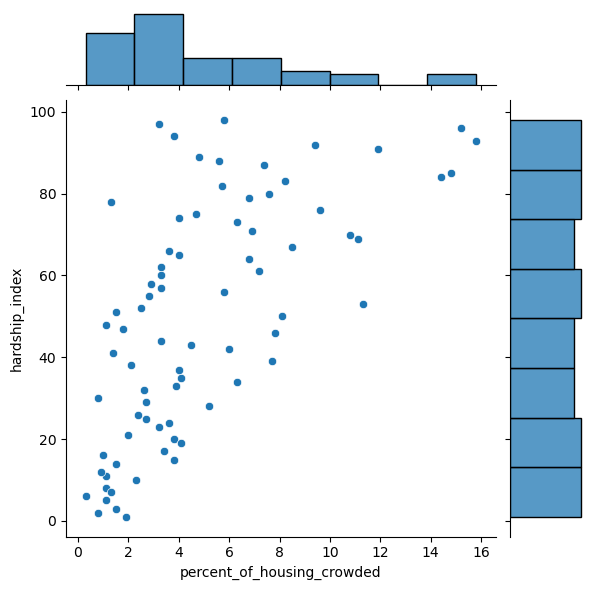

In [29]:
Housing_Crowded_Vs_Hardship_Index = %sql SELECT percent_of_housing_crowded, hardship_index FROM chicago_socioeconomic_data;
plot = sns.jointplot(x='percent_of_housing_crowded', y='hardship_index', data=Housing_Crowded_Vs_Hardship_Index.DataFrame())